Running AlievPanfilovFEM: 100%|██████████| 1/1 [00:00<00:00,  3.25it/s]


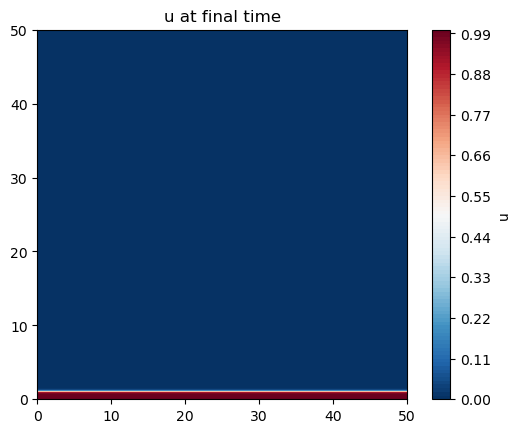

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import finitewave as fw


def build_triangular_mesh(n, m, x_range=(0, 1), y_range=(0, 1)):
    x = np.linspace(x_range[0], x_range[1], n+1)
    y = np.linspace(y_range[0], y_range[1], m+1)
    xv, yv = np.meshgrid(x, y)
    coords = np.vstack([xv.ravel(), yv.ravel(), np.zeros((n+1)*(m+1))]).T

    elems = []
    for j in range(m):
        for i in range(n):
            v0 = j * (n + 1) + i
            v1 = v0 + 1
            v2 = v0 + (n + 1)
            v3 = v2 + 1
            elems.append([v0, v1, v3])
            elems.append([v0, v3, v2])
    elems = np.array(elems)

    return coords, elems


# create a tissue of size 400x400 with cardiomycytes:
n = 1000
size = 50

coords, elems = build_triangular_mesh(n, n, (0, size), (0, size))

tissue = fw.CardiacTissueFEM(coords, elems)
# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoordFEM(0, 1, 0, size, 0, 1))
stim_sequence.add_stim(fw.StimVoltageCoordFEM(45, 1, 0, size//2, 0, size))

# create model object and set up parameters:
aliev_panfilov = fw.AlievPanfilovFEM()
aliev_panfilov.dt = 0.01
aliev_panfilov.t_max = 0.01
# add the tissue and the stim parameters to the model object:
aliev_panfilov.cardiac_tissue = tissue
aliev_panfilov.stim_sequence = stim_sequence

# run the model:
aliev_panfilov.run(num_of_threads=1)

u = aliev_panfilov.u

# show the potential map at the end of calculations:
plt.figure()
plt.tricontourf(coords[:, 0], coords[:, 1], elems, u, levels=100,
                cmap="RdBu_r")
plt.colorbar(label='u')
plt.title('u at final time')
plt.gca().set_aspect('equal')
plt.show()

In [8]:
A, M = aliev_panfilov.weights

A.indptr, A.indices, A.data, M.indptr, M.indices, M.data

(array([      0,       4,       9, ..., 7005992, 7005997, 7006001],
       dtype=int32),
 array([      0,       1,    1001, ..., 1000999, 1001999, 1002000],
       dtype=int32),
 array([ 0.01041667, -0.00489583, -0.00489583, ..., -0.00489583,
        -0.00489583,  0.01041667]),
 array([      0,       4,       9, ..., 7005992, 7005997, 7006001],
       dtype=int32),
 array([      0,       1,    1001, ..., 1000999, 1001999, 1002000],
       dtype=int32),
 array([0.00041667, 0.00010417, 0.00010417, ..., 0.00010417, 0.00010417,
        0.00041667]))

In [11]:
from numba import njit, prange

@njit(parallel=True)
def csr_matvec(data, indices, indptr, x, y):
    n = indptr.shape[0] - 1
    for i in prange(n):
        start, end = indptr[i], indptr[i+1]
        for j in range(start, end):
            y[i] += data[j] * x[indices[j]]
    return y


# @njit(parallel=True)
def cg_sparse(data, indices, indptr, b, atol=1e-6, maxiter=1000):
    n = len(b)
    x = np.zeros(n, dtype=np.float64)
    q = np.zeros(n, dtype=np.float64)
    r = np.zeros(n, dtype=np.float64)

    r = b - csr_matvec(data, indices, indptr, x, r)

    p = r.copy()
    rs_old = r @ r

    for iteration in range(maxiter):

        if np.linalg.norm(r) < atol:
            return x, 0
        
        rs_new = r @ r
        
        q = csr_matvec(data, indices, indptr, p, q)

        alpha = rs_old / (p @ q)
        x += alpha * p
        r -= alpha * q
        rs_new = r @ r
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new

    return x, maxiter

x = u.copy()
y = np.zeros_like(u)
csr_matvec(A.data, A.indices, A.indptr, x, y)

array([0.00083339, 0.00125005, 0.00125004, ..., 0.        , 0.        ,
       0.        ])

In [12]:
q = np.random.random(u.shape[0]).astype(np.float64)
p = q.copy()
x = np.zeros_like(q)
y = np.zeros_like(q)

%timeit A @ q
%timeit csr_matvec(A.data, A.indices, A.indptr, x, y)
%timeit M @ q
%timeit csr_matvec(M.data, M.indices, M.indptr, x, y)
%timeit p @ q

3.9 ms ± 92.6 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
6.14 ms ± 136 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.16 ms ± 83.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
6.08 ms ± 16.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
483 µs ± 13.2 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [11]:
%timeit M.dot(q)
%timeit M @ q

2.67 ms ± 53.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.83 ms ± 64.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
import numpy as np

x = np.random.random((256, 256, 256))
y = np.random.random((256, 256, 256))

if x.ndim == 2:
    slices = (slice(100, 110), slice(100, 110))
elif x.ndim == 3:
    slices = (slice(100, 110), slice(100, 110), slice(100, 110))

%timeit x[slices]

38.9 ms ± 467 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [14]:
import numpy as np

class A:
    def __init__(self):
        self.state_vars = ["u", "v"]
        self.init_u = 0.
        self.init_v = 0.
        self.m = np.arange(5)

    def init_state_vars(self):
        for var in self.state_vars:
            val = getattr(self, "init_" + var)
            val = np.full_like(self.m, val)
            setattr(self, "_" + var, val)

    def __getattr__(self, name):
        if name in self.state_vars:
            return getattr(self, "_" + name)

    def __setattr__(self, name, value):
        """Allow assignment like a.u = new_array."""
        if "state_vars" in self.__dict__ and name in self.state_vars:
            setattr(self, "_" + name, value)
            return
        
        super().__setattr__(name, value)

a = A()
a.init_state_vars()

print(a.u)
print(a.v)

a.u = 1.
a.v = 2.

print(a.u)
print(a.v)

print(a._u)
print(a._v)




[0 0 0 0 0]
[0 0 0 0 0]
1.0
2.0
1.0
2.0
